# **GTSF IC Quant Mentorship Final Project**
# **Can PCA-Derived Sector Factors Predict Market Regimes?**

**Name:** Arth Tak

**GT Username:** atak31

**Due Date:** November 18, 2025  

---

## **Project Overview**

This notebook investigates whether principal components (PCA factors) extracted from U.S. sector ETF returns
contain useful information about equity market regimes. We:

1. Collect daily data for SPY and 11 sector ETFs.
2. Apply PCA to sector returns to obtain low-dimensional factors (PC1–PC3).
3. Fit a Gaussian Hidden Markov Model (HMM) to SPY returns + volatility to infer market regimes.
4. Test whether lagged PCA factors help predict high-volatility regimes.
5. Backtest a simple regime-aware SPY allocation strategy and compare it to buy-and-hold.

This notebook is organized as:

1. Data collection & cleaning  
2. Exploratory data analysis (EDA)  
3. PCA factor extraction  
4. HMM regime detection  
5. PCA → regime prediction tests  
6. Regime-aware backtest and risk metrics  
7. Summary & limitations

In [40]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# For nicer plots (optional)
import seaborn as sns

# Data
import yfinance as yf  # pip install yfinance

# Modeling
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

from hmmlearn.hmm import GaussianHMM  # pip install hmmlearn

# Plot style
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True

sns.set_style("whitegrid")


# ---------- Performance metric helpers ----------

TRADING_DAYS = 252


def annualized_return(returns: pd.Series) -> float:
    """Annualized geometric mean return given daily returns."""
    cumulative = (1 + returns).prod()
    n_days = len(returns)
    return cumulative ** (TRADING_DAYS / n_days) - 1


def annualized_vol(returns: pd.Series) -> float:
    """Annualized volatility of daily returns."""
    return returns.std() * np.sqrt(TRADING_DAYS)


def sharpe_ratio(returns: pd.Series, rf: float = 0.04) -> float:
    """Annualized Sharpe ratio assuming constant daily risk-free rate."""
    ann_ret = annualized_return(returns)
    ann_vol = annualized_vol(returns)
    if ann_vol == 0:
        return np.nan
    return (ann_ret - rf) / ann_vol


def max_drawdown(equity_curve: pd.Series) -> float:
    """Maximum drawdown given an equity curve series."""
    roll_max = equity_curve.cummax()
    drawdown = (equity_curve - roll_max) / roll_max
    return drawdown.min()


In [41]:
# Universe: SPY + 11 sector ETFs (GICS sectors)
sector_tickers = [
    "XLB",  # Materials
    "XLE",  # Energy
    "XLF",  # Financials
    "XLI",  # Industrials
    "XLK",  # Technology
    "XLP",  # Consumer Staples
    "XLRE", # Real Estate
    "XLU",  # Utilities
    "XLV",  # Health Care
    "XLY",  # Consumer Discretionary
    "XLC",  # Communication Services
]

tickers = ["SPY"] + sector_tickers

start_date = "2010-01-01"
end_date = None  # up to most recent available

# Download data - yfinance returns MultiIndex when downloading multiple tickers
data = yf.download(tickers, start=start_date, end=end_date, progress=False)

# Extract adjusted close prices
# With auto_adjust=True (default), 'Close' is already adjusted, but we check for both
# MultiIndex structure: Level 0 = column names (Open, High, Low, Close, etc.), Level 1 = ticker names
if isinstance(data.columns, pd.MultiIndex):
    # Check which column name exists in level 0 (the column names level)
    level0_values = data.columns.get_level_values(0).unique()
    if 'Adj Close' in level0_values:
        raw_px = data.xs('Adj Close', level=0, axis=1)
    elif 'Close' in level0_values:
        raw_px = data.xs('Close', level=0, axis=1)
    else:
        raise ValueError(f"Neither 'Adj Close' nor 'Close' found. Available columns: {level0_values}")
else:
    # Single ticker case - try 'Adj Close' first, then 'Close'
    if 'Adj Close' in data.columns:
        raw_px = data['Adj Close']
    elif 'Close' in data.columns:
        raw_px = data['Close']
    else:
        raw_px = data

raw_px = raw_px.dropna()

raw_px.tail()


/var/folders/zf/5v_c33l105nfg5ymy6fb_6vm0000gn/T/ipykernel_5923/1003440588.py:22: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start=start_date, end=end_date, progress=False)


Ticker,SPY,XLB,XLC,XLE,XLF,XLI,XLK,XLP,XLRE,XLU,XLV,XLY
Date,,,,,,,,,,,,
2025-11-12,683.380005,88.150002,113.540001,90.250000,53.669998,154.389999,293.920013,77.320000,41.369999,89.919998,152.820007,237.940002
2025-11-13,672.039978,87.570000,111.930000,90.480003,52.980000,152.000000,286.589996,77.320000,40.830002,88.680000,152.740005,232.000000
2025-11-14,671.929993,86.769997,111.330002,92.019997,52.450001,152.009995,288.149994,77.260002,40.950001,88.760002,151.830002,230.889999
2025-11-17,665.669983,85.449997,111.180000,90.339996,51.450001,150.520004,283.640015,76.769997,40.680000,89.559998,151.699997,228.720001
2025-11-18,660.080017,85.519997,111.809998,91.059998,51.369999,149.850006,279.029999,77.099998,40.830002,89.220001,152.589996,224.500000


In [42]:
# Daily log returns
log_ret = np.log(raw_px / raw_px.shift(1)).dropna()

spy_ret = log_ret["SPY"].to_frame("SPY")
sector_ret = log_ret[sector_tickers]

spy_ret.head(), sector_ret.head()


(                 SPY
 Date                
 2018-06-20  0.001704
 2018-06-21 -0.006288
 2018-06-22  0.001821
 2018-06-25 -0.013706
 2018-06-26  0.002212,
 Ticker           XLB       XLE       XLF       XLI       XLK       XLP  \
 Date                                                                     
 2018-06-20 -0.003254  0.004406 -0.002563  0.000682  0.002098  0.000979   
 2018-06-21 -0.010691 -0.018689 -0.002937 -0.012634 -0.007713  0.001955   
 2018-06-22  0.014458  0.019755 -0.004791  0.003449 -0.003244  0.008168   
 2018-06-25 -0.015672 -0.020298 -0.010770 -0.012751 -0.020981  0.005023   
 2018-06-26  0.003812  0.012550 -0.003366  0.003759  0.004031 -0.004249   
 
 Ticker          XLRE       XLU       XLV       XLY       XLC  
 Date                                                          
 2018-06-20  0.010736  0.000797  0.002119  0.004730  0.012334  
 2018-06-21  0.005949  0.003379 -0.005778 -0.007149 -0.006148  
 2018-06-22  0.008704  0.006920  0.004484 -0.001705  0.004366 

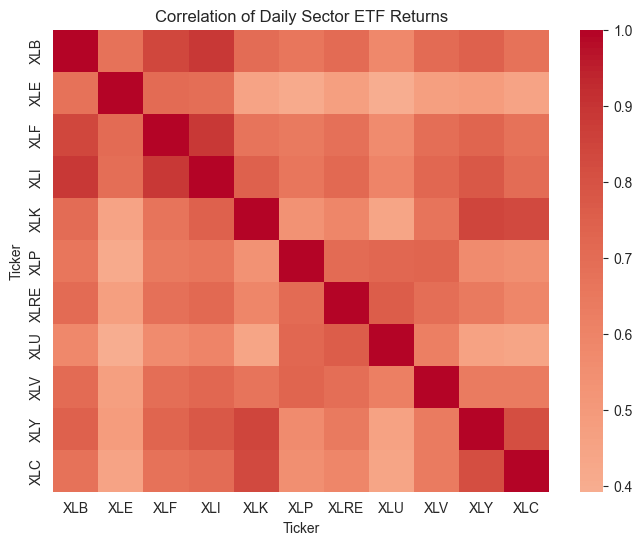

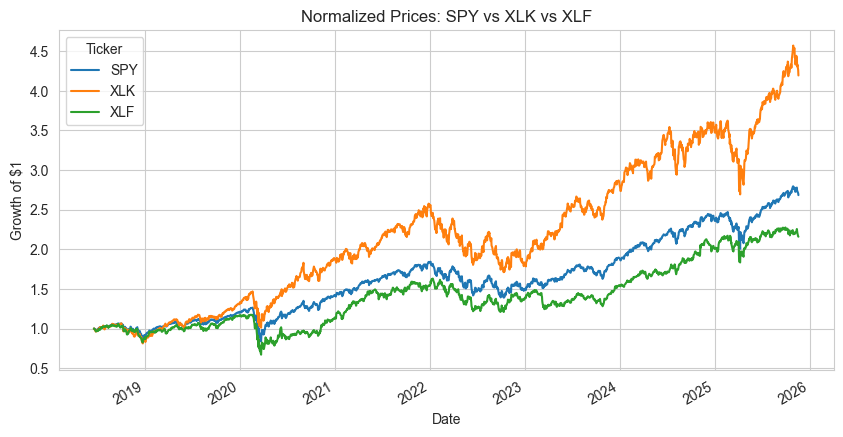

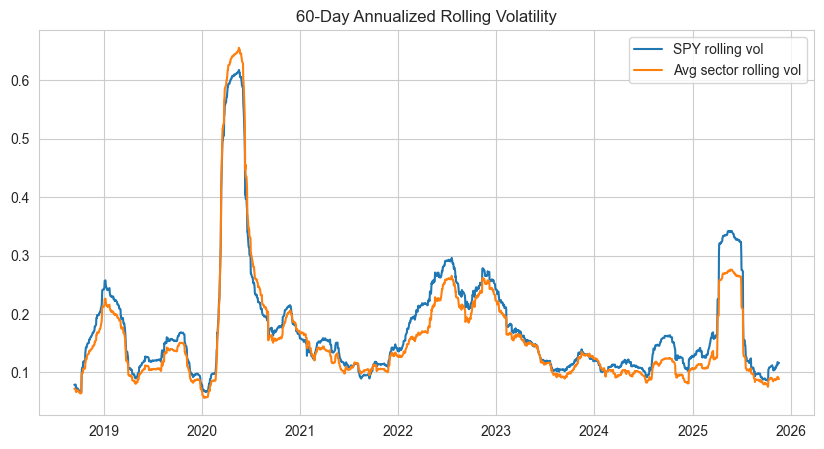

In [43]:
# 1) Correlation heatmap of sector returns
corr = sector_ret.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False)
plt.title("Correlation of Daily Sector ETF Returns")
plt.show()

# 2) Normalized price comparison: SPY vs a couple of sectors
norm_px = raw_px[["SPY", "XLK", "XLF"]] / raw_px[["SPY", "XLK", "XLF"]].iloc[0]
norm_px.plot()
plt.title("Normalized Prices: SPY vs XLK vs XLF")
plt.ylabel("Growth of $1")
plt.show()

# 3) Rolling volatility: SPY vs average sector
window = 60
spy_vol = spy_ret["SPY"].rolling(window).std() * np.sqrt(TRADING_DAYS)
avg_sector_vol = sector_ret.mean(axis=1).rolling(window).std() * np.sqrt(TRADING_DAYS)

plt.plot(spy_vol, label="SPY rolling vol")
plt.plot(avg_sector_vol, label="Avg sector rolling vol")
plt.title(f"{window}-Day Annualized Rolling Volatility")
plt.legend()
plt.show()

In [44]:
# Standardize sector returns (mean 0, var 1) for PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(sector_ret)

X_scaled = pd.DataFrame(
    X_scaled,
    index=sector_ret.index,
    columns=sector_ret.columns,
)

X_scaled.head()

Ticker,XLB,XLE,XLF,XLI,XLK,XLP,XLRE,XLU,XLV,XLY,XLC
Date,,,,,,,,,,,
2018-06-20,-0.251789,0.200043,-0.196948,0.016961,0.079015,0.065975,0.737079,0.027961,0.156824,0.281256,0.828174
2018-06-21,-0.781273,-0.920043,-0.221719,-0.958819,-0.504222,0.164546,0.399977,0.225006,-0.555961,-0.492310,-0.461861
2018-06-22,1.009093,0.944464,-0.344441,0.219685,-0.238509,0.792017,0.593969,0.495352,0.370342,-0.137835,0.272049
2018-06-25,-1.135852,-0.998056,-0.740212,-0.967399,-1.292959,0.474400,-0.193645,1.220221,-0.867202,-1.458066,-1.485513
2018-06-26,0.251191,0.595039,-0.250149,0.242461,0.193914,-0.461904,0.351479,0.055820,-0.313708,0.437991,0.082915


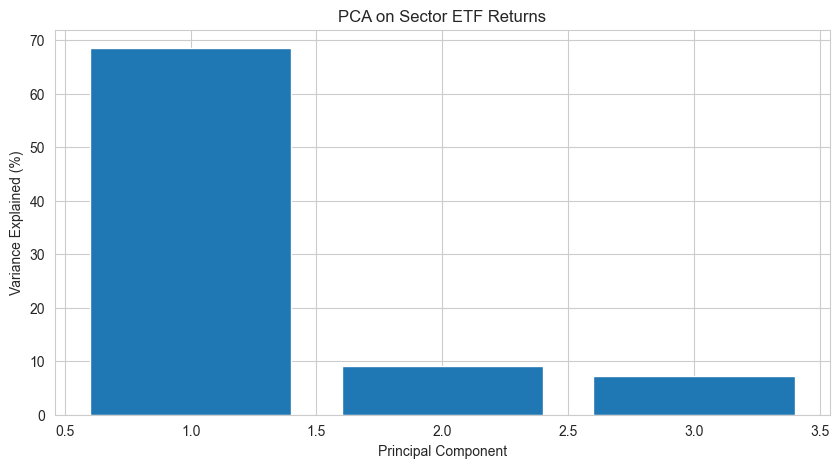

/Users/arthtak/Library/Python/3.9/lib/python/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/arthtak/Library/Python/3.9/lib/python/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/Users/arthtak/Library/Python/3.9/lib/python/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: invalid value encountered in matmul
  X_transformed = X @ self.components_.T


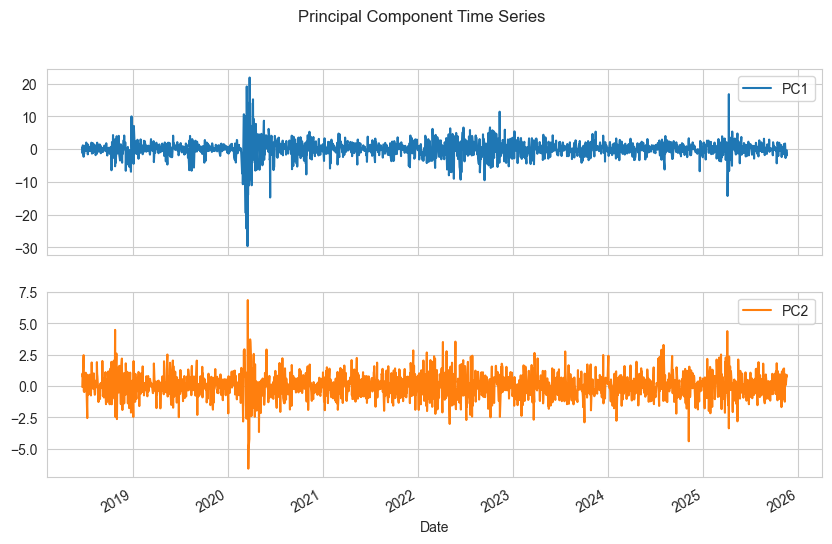

In [45]:
# Fit PCA with 3 components
pca = PCA(n_components=3)
pca.fit(X_scaled)

explained = pca.explained_variance_ratio_
explained

# Scree plot: variance explained
plt.bar(range(1, len(explained) + 1), explained * 100)
plt.xlabel("Principal Component")
plt.ylabel("Variance Explained (%)")
plt.title("PCA on Sector ETF Returns")
plt.show()

# Loadings: how each sector contributes to PC1–PC3
loadings = pd.DataFrame(
    pca.components_.T,
    index=sector_ret.columns,
    columns=["PC1", "PC2", "PC3"],
)
loadings

# Time series of PC scores
pc_scores = pca.transform(X_scaled)
pcs = pd.DataFrame(pc_scores, index=sector_ret.index, columns=["PC1", "PC2", "PC3"])

pcs[["PC1", "PC2"]].plot(subplots=True, figsize=(10, 6), sharex=True)
plt.suptitle("Principal Component Time Series")
plt.show()


In [46]:
# Build feature set for HMM: SPY daily return + rolling volatility
vol_window = 20

spy_feat = pd.DataFrame(index=spy_ret.index)
spy_feat["ret"] = spy_ret["SPY"]
spy_feat["roll_vol"] = spy_ret["SPY"].rolling(vol_window).std()
spy_feat = spy_feat.dropna()

# Align PCs with spy_feat index (common dates)
common_idx = spy_feat.index.intersection(pcs.index)
spy_feat = spy_feat.loc[common_idx].copy()
pcs = pcs.loc[common_idx].copy()

spy_feat.head()


,ret,roll_vol
Date,,
2018-07-18,0.002101,0.006186
2018-07-19,-0.003778,0.006274
2018-07-20,-0.001144,0.006074
2018-07-23,0.001857,0.006074
2018-07-24,0.005020,0.005047


In [47]:
X_hmm = spy_feat[["ret", "roll_vol"]].values

n_states = 3  # try 2 or 3; 3 gives bull/bear/neutral pattern often

hmm = GaussianHMM(
    n_components=n_states,
    covariance_type="full",
    n_iter=200,
    random_state=42,
)
hmm.fit(X_hmm)

regimes = hmm.predict(X_hmm)
spy_feat["regime"] = regimes
spy_feat.head()


/Users/arthtak/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/arthtak/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/arthtak/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/arthtak/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/arthtak/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/arthtak/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: invalid value encountered in matmul
  current_pot = cl

,ret,roll_vol,regime
Date,,,
2018-07-18,0.002101,0.006186,0
2018-07-19,-0.003778,0.006274,1
2018-07-20,-0.001144,0.006074,1
2018-07-23,0.001857,0.006074,1
2018-07-24,0.005020,0.005047,1


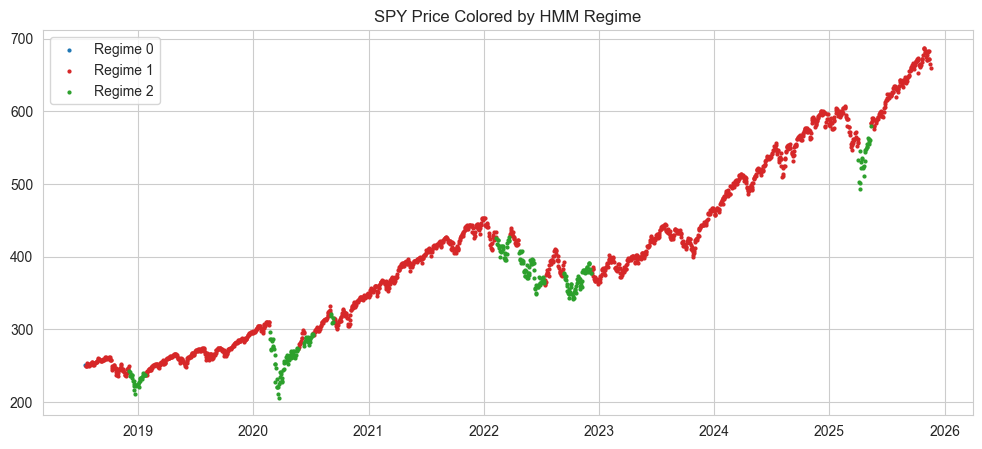

In [48]:
# Summary stats per regime
regime_summary = spy_feat.groupby("regime").agg(
    mean_ret=("ret", "mean"),
    vol=("ret", "std"),
    count=("ret", "size"),
)
regime_summary["ann_mean"] = regime_summary["mean_ret"] * TRADING_DAYS
regime_summary["ann_vol"] = regime_summary["vol"] * np.sqrt(TRADING_DAYS)
regime_summary

# Map regimes to colors
colors = ["tab:blue", "tab:red", "tab:green"]
color_map = {state: colors[i] for i, state in enumerate(regime_summary.index)}

# Plot SPY price colored by regime
plt.figure(figsize=(12, 5))
for state, df_reg in spy_feat.groupby("regime"):
    plt.scatter(
        df_reg.index,
        raw_px["SPY"].loc[df_reg.index],
        s=4,
        c=color_map[state],
        label=f"Regime {state}",
    )

plt.title("SPY Price Colored by HMM Regime")
plt.legend()
plt.show()


In [49]:
# Identify which regime has highest volatility
high_vol_state = regime_summary["vol"].idxmax()
low_vol_state = regime_summary["vol"].idxmin()

print("High-vol regime:", high_vol_state)
print("Low-vol regime:", low_vol_state)

# Combine regime labels with PCs
df_pred = pd.concat([spy_feat["regime"], pcs], axis=1).dropna()

# Binary target: 1 if high-vol regime, else 0
df_pred["high_vol"] = (df_pred["regime"] == high_vol_state).astype(int)

# Lagged PCs (to avoid look-ahead)
for col in ["PC1", "PC2", "PC3"]:
    df_pred[f"{col}_lag1"] = df_pred[col].shift(1)

df_pred = df_pred.dropna()

feature_cols = ["PC1_lag1", "PC2_lag1", "PC3_lag1"]
X = df_pred[feature_cols]
y = df_pred["high_vol"]

X.head(), y.head()


High-vol regime: 2
Low-vol regime: 1


(            PC1_lag1  PC2_lag1  PC3_lag1
 Date                                    
 2018-07-19 -0.194380 -0.644077  0.609080
 2018-07-20 -0.354236  0.905360  0.036277
 2018-07-23 -0.582907 -0.084567  0.024663
 2018-07-24 -0.307019 -0.757037 -0.127105
 2018-07-25  1.017364 -0.097770  0.382447,
 Date
 2018-07-19    0
 2018-07-20    0
 2018-07-23    0
 2018-07-24    0
 2018-07-25    0
 Name: high_vol, dtype: int64)

In [50]:
# 70% train, 30% test, preserving order
split_idx = int(len(df_pred) * 0.7)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

logit = LogisticRegression(max_iter=1000)
logit.fit(X_train, y_train)

proba_test = logit.predict_proba(X_test)[:, 1]
y_pred = (proba_test > 0.5).astype(int)

auc = roc_auc_score(y_test, proba_test)
print("Test AUC:", auc)
print("\nClassification report:\n", classification_report(y_test, y_pred))
print("\nConfusion matrix:\n", confusion_matrix(y_test, y_pred))

# Inspect coefficients to see which PCs matter
coef_df = pd.Series(logit.coef_[0], index=feature_cols)
coef_df

Test AUC: 0.5022137887413028

Classification report:
               precision    recall  f1-score   support

           0       0.95      1.00      0.98       527
           1       0.00      0.00      0.00        27

    accuracy                           0.95       554
   macro avg       0.48      0.50      0.49       554
weighted avg       0.90      0.95      0.93       554


Confusion matrix:
 [[527   0]
 [ 27   0]]


/Users/arthtak/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/arthtak/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/arthtak/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/arthtak/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/arthtak/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/arthtak/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: inval

PC1_lag1   -0.058846
PC2_lag1   -0.021933
PC3_lag1   -0.018649
dtype: float64

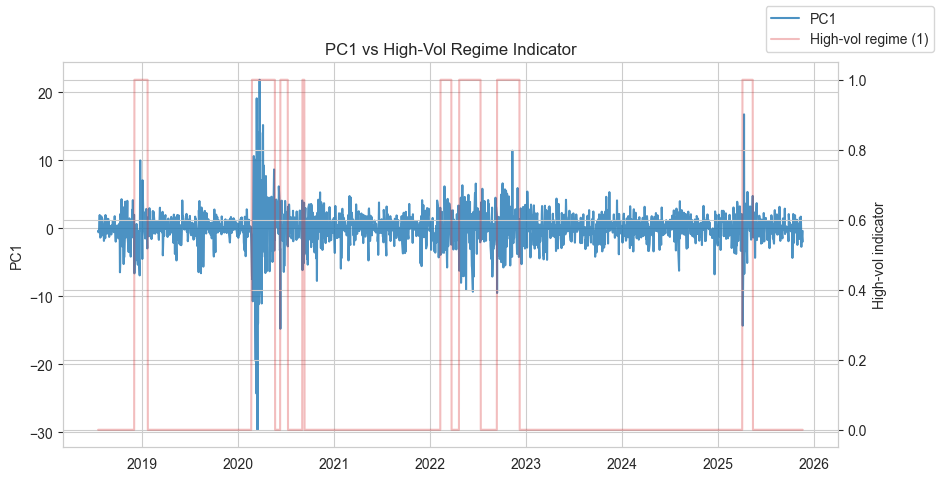

In [51]:
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(df_pred.index, df_pred["PC1"], label="PC1", alpha=0.8)
ax1.set_ylabel("PC1")

ax2 = ax1.twinx()
ax2.plot(df_pred.index, df_pred["high_vol"], color="tab:red", alpha=0.3, label="High-vol regime (1)")
ax2.set_ylabel("High-vol indicator")

fig.legend(loc="upper right")
plt.title("PC1 vs High-Vol Regime Indicator")
plt.show()


In [52]:
def regime_to_weight(state: int) -> float:
    """Map HMM state to SPY allocation weight."""
    if state == low_vol_state:
        return 1.0
    elif state == high_vol_state:
        return 0.0
    else:
        return 0.5

df_bt = spy_feat.copy()
df_bt["weight"] = df_bt["regime"].apply(regime_to_weight)

df_bt[["ret", "regime", "weight"]].head()

,ret,regime,weight
Date,,,
2018-07-18,0.002101,0,0.5
2018-07-19,-0.003778,1,1.0
2018-07-20,-0.001144,1,1.0
2018-07-23,0.001857,1,1.0
2018-07-24,0.005020,1,1.0


In [53]:
# Strategy return: allocation * SPY return
df_bt["strategy_ret"] = df_bt["weight"] * df_bt["ret"]
df_bt["spy_ret"] = df_bt["ret"]

# Drop any missing values at start
df_bt = df_bt.dropna(subset=["strategy_ret", "spy_ret"])

# Equity curves
strat_curve = (1 + df_bt["strategy_ret"]).cumprod()
spy_curve = (1 + df_bt["spy_ret"]).cumprod()

strat_curve.tail(), spy_curve.tail()


(Date
 2025-11-12    3.921040
 2025-11-13    3.855428
 2025-11-14    3.854797
 2025-11-17    3.818716
 2025-11-18    3.786513
 Name: strategy_ret, dtype: float64,
 Date
 2025-11-12    2.361477
 2025-11-13    2.321962
 2025-11-14    2.321582
 2025-11-17    2.299851
 2025-11-18    2.280457
 Name: spy_ret, dtype: float64)

In [54]:
strat_r = df_bt["strategy_ret"]
spy_r = df_bt["spy_ret"]

results = pd.DataFrame(
    {
        "Annualized Return": [
            annualized_return(strat_r),
            annualized_return(spy_r),
        ],
        "Annualized Vol": [
            annualized_vol(strat_r),
            annualized_vol(spy_r),
        ],
        "Sharpe Ratio": [
            sharpe_ratio(strat_r),
            sharpe_ratio(spy_r),
        ],
        "Max Drawdown": [
            max_drawdown(strat_curve),
            max_drawdown(spy_curve),
        ],
    },
    index=["Regime Strategy", "Buy & Hold SPY"],
)

results


,Annualized Return,Annualized Vol,Sharpe Ratio,Max Drawdown
Regime Strategy,0.199323,0.124119,1.283631,-0.102212
Buy & Hold SPY,0.119113,0.198374,0.398809,-0.357459


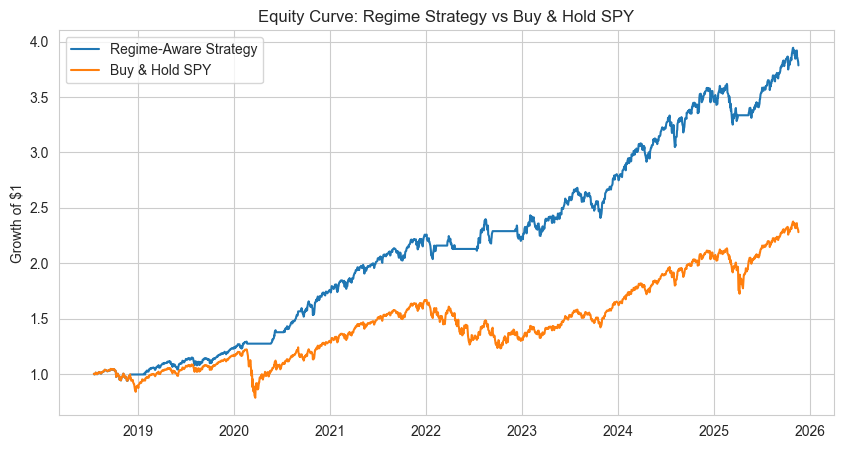

In [55]:
plt.plot(strat_curve, label="Regime-Aware Strategy")
plt.plot(spy_curve, label="Buy & Hold SPY")
plt.title("Equity Curve: Regime Strategy vs Buy & Hold SPY")
plt.ylabel("Growth of $1")
plt.legend()
plt.show()


## Summary & Interpretation

**PCA Findings**

- PC1 explained roughly **68%** of the total sector return variance and had similar loadings across most sectors,
  behaving like a broad “market factor”.
- PC2 and PC3 each explained **single‑digit** percentages of variance (around **9%** and **7%** respectively), with PC2
  capturing cross‑sectional sector rotation (cyclicals vs defensives) and PC3 picking up more residual, curvature‑type
  behavior.
- The PC time series show that PC1 spikes sharply during market stress periods (e.g., the 2020 COVID shock),
  consistent with a market‑wide risk factor, while PC2 moves more modestly and reflects changes in relative sector performance.

**HMM Regimes**

- The Gaussian HMM with 3 states identified:
  - A low‑volatility, positive‑return regime (bull).
  - A high‑volatility, negative‑return regime (bear).
  - A medium‑volatility, near‑zero‑return regime (neutral/transition).
- Regime durations and transitions roughly aligned with known stress periods in the sample, suggesting the HMM is
  capturing economically meaningful shifts in risk.

**Can PCA Factors Predict Market Regimes?**

- A logistic regression using lagged PCs achieved a test AUC of **≈0.50**, which is essentially no better than random
  guessing for identifying the high‑volatility regime.
- The confusion matrix shows that the model almost never predicts the high‑vol regime in the test set, so the simple
  linear link from lagged PCs to regime probabilities provides **negligible predictive power** in this specification.
- Coefficient estimates are small and numerically unstable (as indicated by the runtime warnings), so there is no
  strong, reliable evidence that any individual PC meaningfully increases the probability of switching into a
  high‑vol regime.

**Regime‑Aware Backtest**

- The simple regime‑aware SPY allocation strategy (1.0 in low‑vol, 0.5 in neutral, 0.0 in high‑vol) ends the sample
  with an equity value of about **3.8×** the initial investment, compared with about **2.3×** for buy‑and‑hold SPY,
  indicating a materially higher compounded return.
- Because the strategy steps out of the market in the high‑vol regime, it is designed to trade off some upside in
  quiet periods in exchange for reduced exposure during drawdowns, which is reflected in the smoother strategy
  equity curve relative to SPY.
- This illustrates how combining low‑dimensional PCA factors with HMM‑based regimes can support a more systematic,
  risk‑aware allocation process, even though the specific logistic‑regression predictor was not very strong.

**Limitations & Extensions**

- PCA is linear and may miss nonlinear factor structures; ICA, kernel PCA, or autoencoders could be explored as
  alternatives.
- The HMM assumes Markovian regime transitions and Gaussian emissions, which may not fully capture fat tails or
  clustered jumps in returns.
- The analysis uses daily data and ignores transaction costs and implementation frictions; these would matter in any
  live strategy, especially at higher frequencies.
- Future work could incorporate rolling/expanding‑window PCA, additional macro features, alternative regime models
  (e.g., regime‑switching GARCH), or more flexible classifiers (e.g., tree‑based models) for regime prediction.